In [1]:
import cv2
import numpy as np
from matplotlib import pyplot as plt

Image loaded
Image shape: (720, 625, 3)


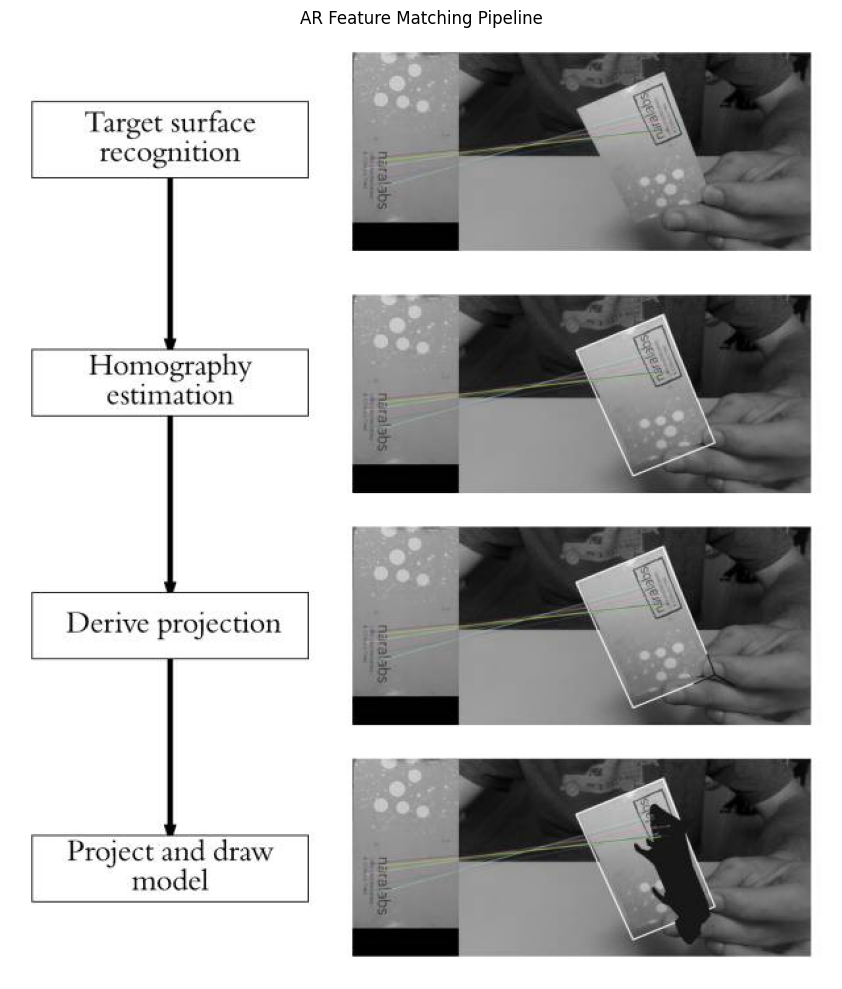

In [2]:
# Path to the image
path = "AR Pipeline.jpeg"
img = cv2.imread(path)

print("Image loaded")
print("Image shape:", img.shape)

# Convert BGR to RGB
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

# Display image
plt.figure(figsize=(16, 10))
plt.imshow(img_rgb)
plt.title("AR Feature Matching Pipeline")
plt.axis("off")
plt.tight_layout()
plt.show()

In [3]:
# Path
ref_path = "left_view.png"
scene_path = "right_view.png"

# Read images
reference_img = cv2.imread(ref_path)
scene_img = cv2.imread(scene_path)

if reference_img is None or scene_img is None:
    print("Error loading images")
    exit()

print("Reference:", reference_img.shape)
print("Scene:", scene_img.shape)

ref_h, ref_w = reference_img.shape[:2]

# Convert to grayscale
ref_gray = cv2.cvtColor(reference_img, cv2.COLOR_BGR2GRAY)
scene_gray = cv2.cvtColor(scene_img, cv2.COLOR_BGR2GRAY)

print("Images loaded")

Reference: (298, 397, 3)
Scene: (298, 397, 3)
Images loaded


Reference Keypoints: 993
Scene Keypoints: 976


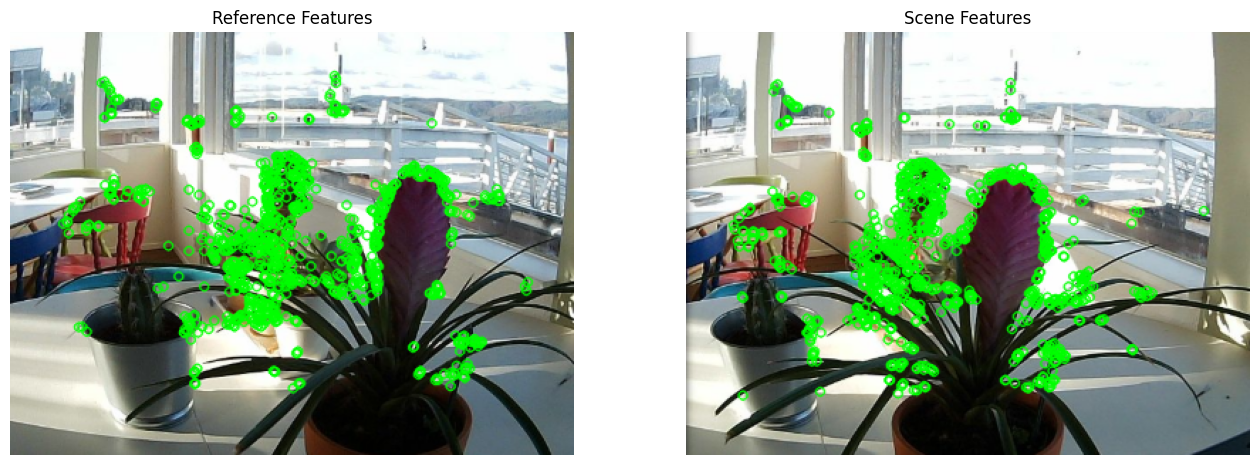

In [4]:
# Step 1: ORB feature detection
orb = cv2.ORB_create(nfeatures=1000)

ref_kp, ref_desc = orb.detectAndCompute(ref_gray, None)
scene_kp, scene_desc = orb.detectAndCompute(scene_gray, None)

print("Reference Keypoints:", len(ref_kp))
print("Scene Keypoints:", len(scene_kp))

ref_vis = cv2.drawKeypoints(reference_img, ref_kp, None, color=(0,255,0))
scene_vis = cv2.drawKeypoints(scene_img, scene_kp, None, color=(0,255,0))

plt.figure(figsize=(16,6))

plt.subplot(1,2,1)
plt.imshow(cv2.cvtColor(ref_vis, cv2.COLOR_BGR2RGB))
plt.title("Reference Features")
plt.axis("off")

plt.subplot(1,2,2)
plt.imshow(cv2.cvtColor(scene_vis, cv2.COLOR_BGR2RGB))
plt.title("Scene Features")
plt.axis("off")

plt.show()

Total raw matches: 993
Good matches: 65
Match quality: 6.55 %


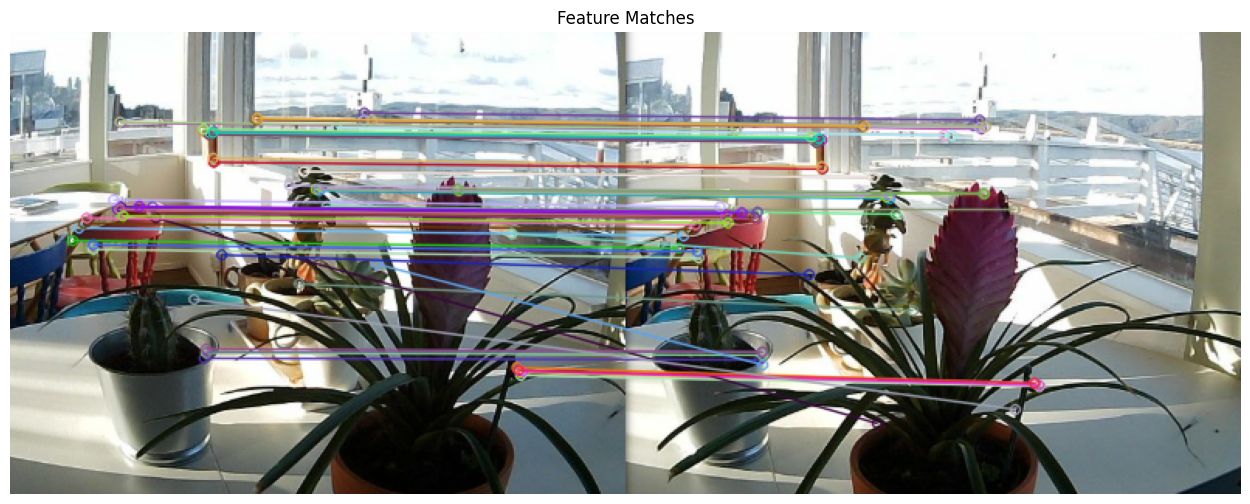

In [5]:
# Step 2: Feature Matching

# Match descriptors
bf = cv2.BFMatcher(cv2.NORM_HAMMING, crossCheck=False)
matches = bf.knnMatch(ref_desc, scene_desc, k=2)

# Lowe's ratio test
good_matches = []
for pair in matches:
    if len(pair) == 2:
        m, n = pair
        if m.distance < 0.75 * n.distance:
            good_matches.append(m)

print("Total raw matches:", len(matches))
print("Good matches:", len(good_matches))

if len(matches) > 0:
    print("Match quality:", round(len(good_matches)/len(matches)*100, 2), "%")
    
match_img = cv2.drawMatches(reference_img, ref_kp,
                             scene_img, scene_kp,
                             good_matches[:100], None, flags=2)

plt.figure(figsize=(18,6))
plt.imshow(cv2.cvtColor(match_img, cv2.COLOR_BGR2RGB))
plt.title("Feature Matches")
plt.axis("off")
plt.show()

Reference points: (65, 2)
Scene points: (65, 2)

Homography matrix:
 [[ 9.19756551e-01 -2.99038281e-02  1.11785811e+01]
 [-1.70128959e-02  1.26119301e+00 -7.89734934e+00]
 [-5.08388016e-04  1.47437283e-03  1.00000000e+00]]

Inliers: 45
Outliers: 20


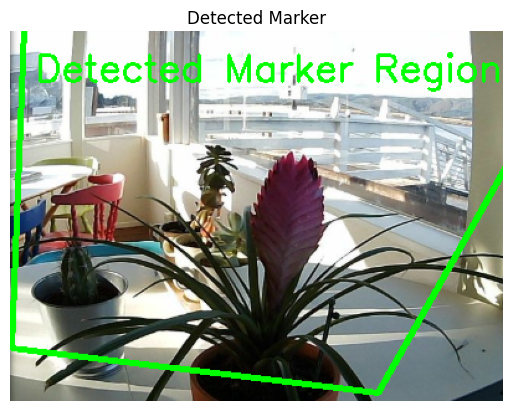

In [6]:
# Step 3: Compute homography
src_pts = np.float32([ref_kp[m.queryIdx].pt for m in good_matches])
dst_pts = np.float32([scene_kp[m.trainIdx].pt for m in good_matches])

print("Reference points:", src_pts.shape)
print("Scene points:", dst_pts.shape)

H, mask = cv2.findHomography(src_pts, dst_pts, cv2.RANSAC, 5.0)

if H is None:
    print("Homography failed")
    exit()

print("\nHomography matrix:\n", H)

inliers = np.sum(mask)
print("\nInliers:", inliers)
print("Outliers:", len(good_matches) - inliers)

# Draw detected region
corners = np.float32([[0,0],[ref_w,0],[ref_w,ref_h],[0,ref_h]])
transformed = cv2.perspectiveTransform(corners.reshape(-1,1,2), H)

scene_marked = scene_img.copy()
cv2.polylines(scene_marked, [np.int32(transformed)], True, (0,255,0), 3)
cv2.putText(scene_marked, "Detected Marker Region",
            (20, 40),
            cv2.FONT_HERSHEY_SIMPLEX,
            1,
            (0, 255, 0),
            2)

plt.imshow(cv2.cvtColor(scene_marked, cv2.COLOR_BGR2RGB))
plt.title("Detected Marker")
plt.axis("off")
plt.show()

In [7]:
# Step 4: Project and Draw 3D models

# Project cube
def project_cube(H, sx, sy, sz):
    pts = np.float32([
        [0,0,0],[sx,0,0],[0,sy,0],[sx,sy,0],
        [0,0,-sz],[sx,0,-sz],[0,sy,-sz],[sx,sy,-sz]
    ])
    out = []
    for p in pts:
        p_h = np.array([p[0], p[1], 1])
        proj = H @ p_h
        out.append(proj[:2]/proj[2])
    return np.array(out)

# Draw cube
def draw_cube(img, pts):
    edges = [(0,1),(1,5),(5,4),(4,0),(2,3),(3,7),(7,6),(6,2),
             (0,2),(1,3),(5,7),(4,6)]
    for s,e in edges:
        cv2.line(img, tuple(map(int, pts[s])), tuple(map(int, pts[e])), (255,0,255), 3)

# Project axes
def project_axes(H, size):
    pts = np.float32([[0,0,0],[size,0,0],[0,size,0],[0,0,-size]])
    out = []
    for p in pts:
        p_h = np.array([p[0], p[1], 1])
        proj = H @ p_h
        out.append(proj[:2]/proj[2])
    return np.array(out)

# Draw axes
def draw_axes(img, pts):
    o = tuple(map(int, pts[0]))
    cv2.line(img, o, tuple(map(int, pts[1])), (0,0,255), 3)
    cv2.line(img, o, tuple(map(int, pts[2])), (0,255,0), 3)
    cv2.line(img, o, tuple(map(int, pts[3])), (255,0,0), 3)

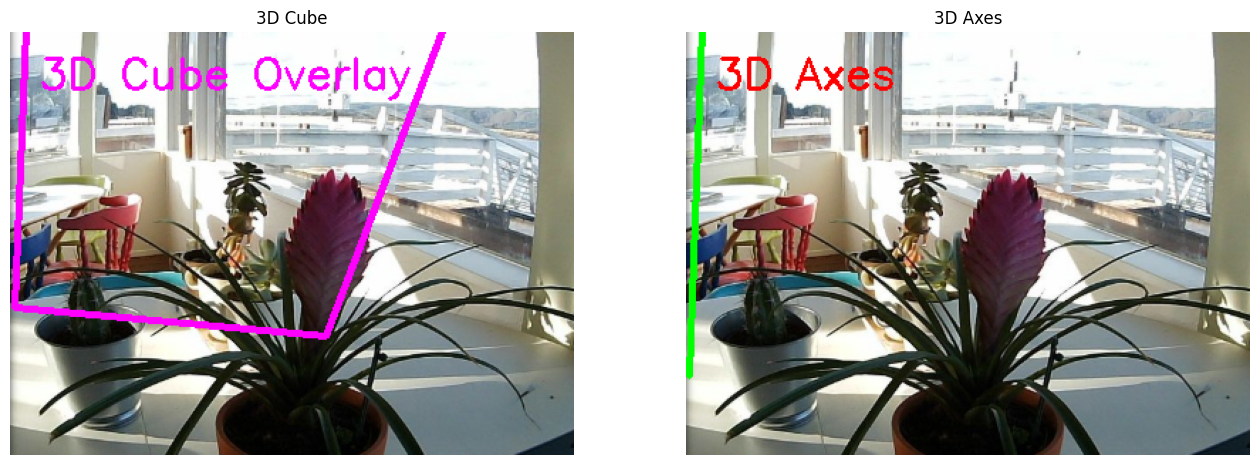

In [8]:
# Step 5: AR Rendering

# Define sizes
sx = int(ref_w * 0.7)
sy = int(ref_h * 0.7)
sz = int(ref_h * 0.6)

# Cube
img_cube = scene_img.copy()
cube_pts = project_cube(H, sx, sy, sz)
draw_cube(img_cube, cube_pts)

cv2.putText(img_cube, "3D Cube Overlay",
            (20, 40),
            cv2.FONT_HERSHEY_SIMPLEX,
            1,
            (255, 0, 255),
            2)

# Axes
img_axes = scene_img.copy()
axes_pts = project_axes(H, max(sx, sy))
draw_axes(img_axes, axes_pts)

cv2.putText(img_axes, "3D Axes",
            (20, 40),
            cv2.FONT_HERSHEY_SIMPLEX,
            1,
            (0, 0, 255),
            2)

plt.figure(figsize=(16,6))

plt.subplot(1,2,1)
plt.imshow(cv2.cvtColor(img_cube, cv2.COLOR_BGR2RGB))
plt.title("3D Cube")
plt.axis("off")

plt.subplot(1,2,2)
plt.imshow(cv2.cvtColor(img_axes, cv2.COLOR_BGR2RGB))
plt.title("3D Axes")
plt.axis("off")

plt.show()

In [9]:
# Summary

print("Features (ref, scene):", len(ref_kp), len(scene_kp))
print("Good matches:", len(good_matches))
print("Inliers:", inliers)

print("AR pipeline complete")

Features (ref, scene): 993 976
Good matches: 65
Inliers: 45
AR pipeline complete
